Nama: Alvin Wijaya

NIM: 2802393062

Data: A - AAPL & AMD

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

# Evaluation Metrics & Utils
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(print(f"Using device: {device}"))

Using device: cpu
None


### A.1 Initial Setup

In [7]:
metric_name = ""
lr = 0.01

In [16]:
# Google Colab
data_path = Path('/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS')

df_aapl = pd.read_csv(data_path / 'AAPL.csv')
df_amd = pd.read_csv(data_path / 'AMD.csv')

### A.2 Explarotary Data Analysis

In [17]:
df_aapl.info(), df_amd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10098 entries, 0 to 10097
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10098 non-null  object 
 1   Open       10098 non-null  float64
 2   High       10098 non-null  float64
 3   Low        10098 non-null  float64
 4   Close      10098 non-null  float64
 5   Adj Close  10098 non-null  float64
 6   Volume     10098 non-null  int64  
dt

(None, None)

Check null value

In [18]:
df_aapl.isna().sum(), df_amd.isna().sum()

(Date         0
 Open         0
 High         0
 Low          0
 Close        0
 Adj Close    0
 Volume       0
 dtype: int64,
 Date         0
 Open         0
 High         0
 Low          0
 Close        0
 Adj Close    0
 Volume       0
 dtype: int64)

Ubah kolom date ke datetime dari object

In [19]:
# Convert 'Date' columns to datetime objects
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_amd['Date'] = pd.to_datetime(df_amd['Date'])

#### A.2.1 Perbandingan Harga Closing

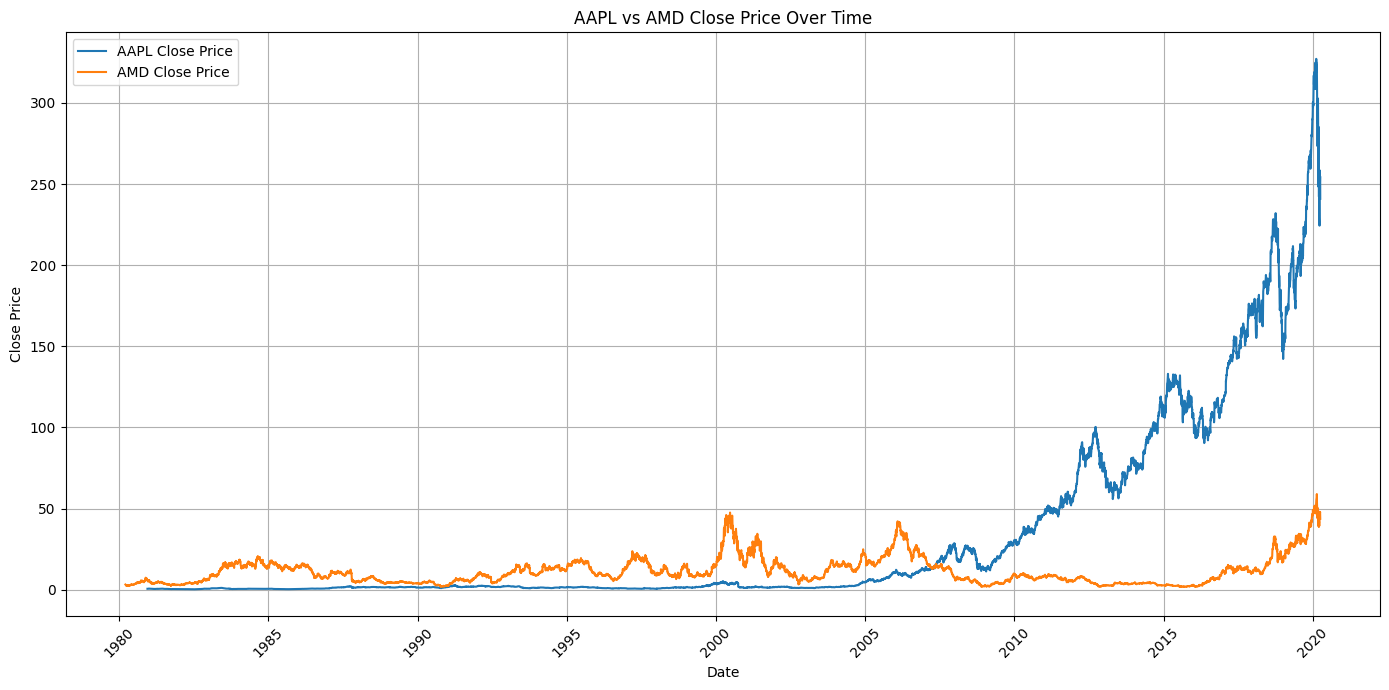

In [20]:
plt.figure(figsize=(14, 7))
plt.plot(df_aapl['Date'], df_aapl['Close'], label='AAPL Close Price')
plt.plot(df_amd['Date'], df_amd['Close'], label='AMD Close Price')

plt.title('AAPL vs AMD Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Secara keseluruhan kedua stock menunjukan pertumbuhan valuasi dalam jangka panjang namun dengan magnitudo pertumbuhan dan konsistensi berbeda.

Gejolak atas dan bawah dapat memberikan petunjuk bahwa sebuah valuasi perusahaan bergerak lebih volatil.

Grafik menunjukan adanya pertumbuhan valuasi kapital yang tinggi oleh perusahaan apple dengan volatilitas keatas dan kebawah.

Sedangkan AMD menunjukan konsistensi valuasi harganya yang tidak berubah banyak selama 40 tahun terakhir.

#### A.2.2 Trading Volume Over Time

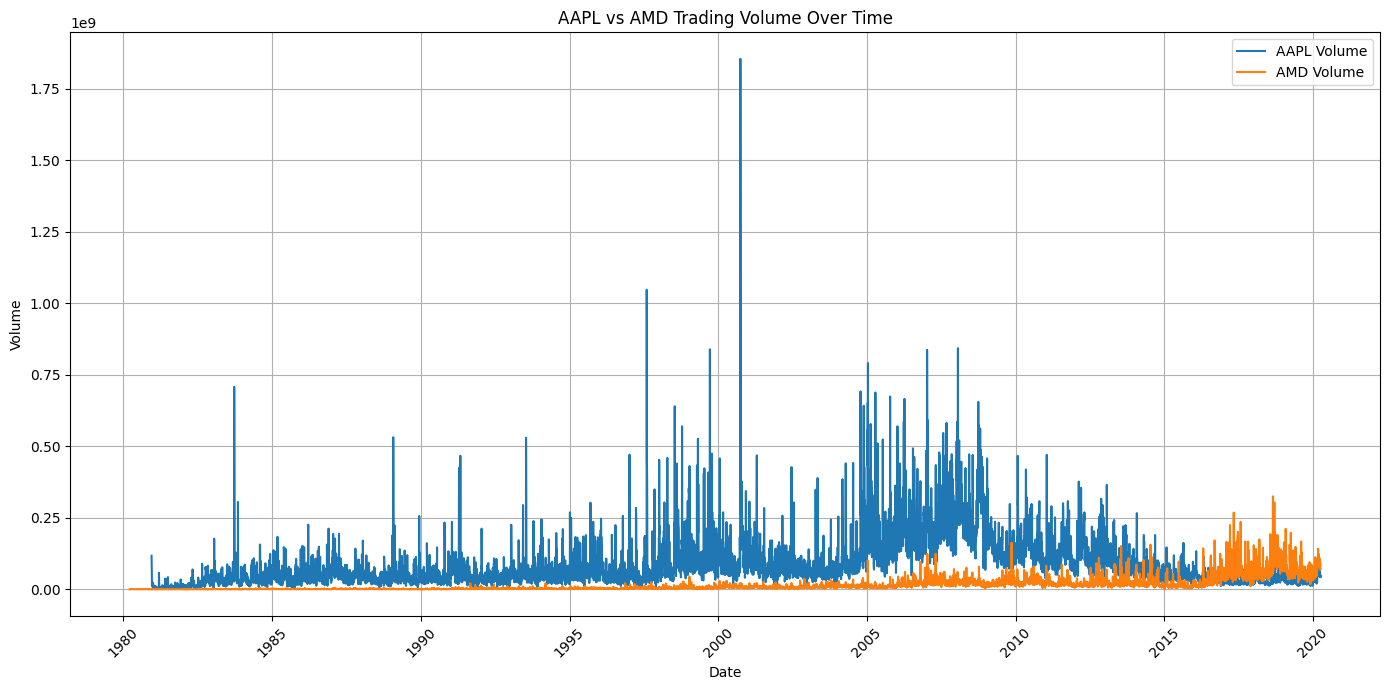

In [21]:
plt.figure(figsize=(14, 7))
plt.plot(df_aapl['Date'], df_aapl['Volume'], label='AAPL Volume')
plt.plot(df_amd['Date'], df_amd['Volume'], label='AMD Volume')

plt.title('AAPL vs AMD Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Graph menunjukan jumlah transaksi volume suatu perusahaan dengan insight:

- Secara umum, semakin besar jumlah volume transaksi saham, maka menggambarkan ketertarikan pasar yang besar.

- Aktivitas transaksi yang tinggi dapat dipicu oleh berita signifikan, laporan keuangan, atau terjadinya fenomena krisis / euphoria pasar.

- Tingginya tren harga berserta lonjakan transaksi volume menandakan tingginya ketertarikan pasar yang tangguh dan sustainable.

- Perusahaan Apple mencatat rekor transaksi besar pada tahun 2000-2005 dan transaksi volume mulai kembali ke tren sebelumnya di 2010-2020.

- Perusahaan AMD memiliki volume transaksi yang sangat konsisten dari 40 tahun belakangan, menandakan aktivitas yang lebih tenang.

#### A.2.3 Distribusi Harga Penutupan

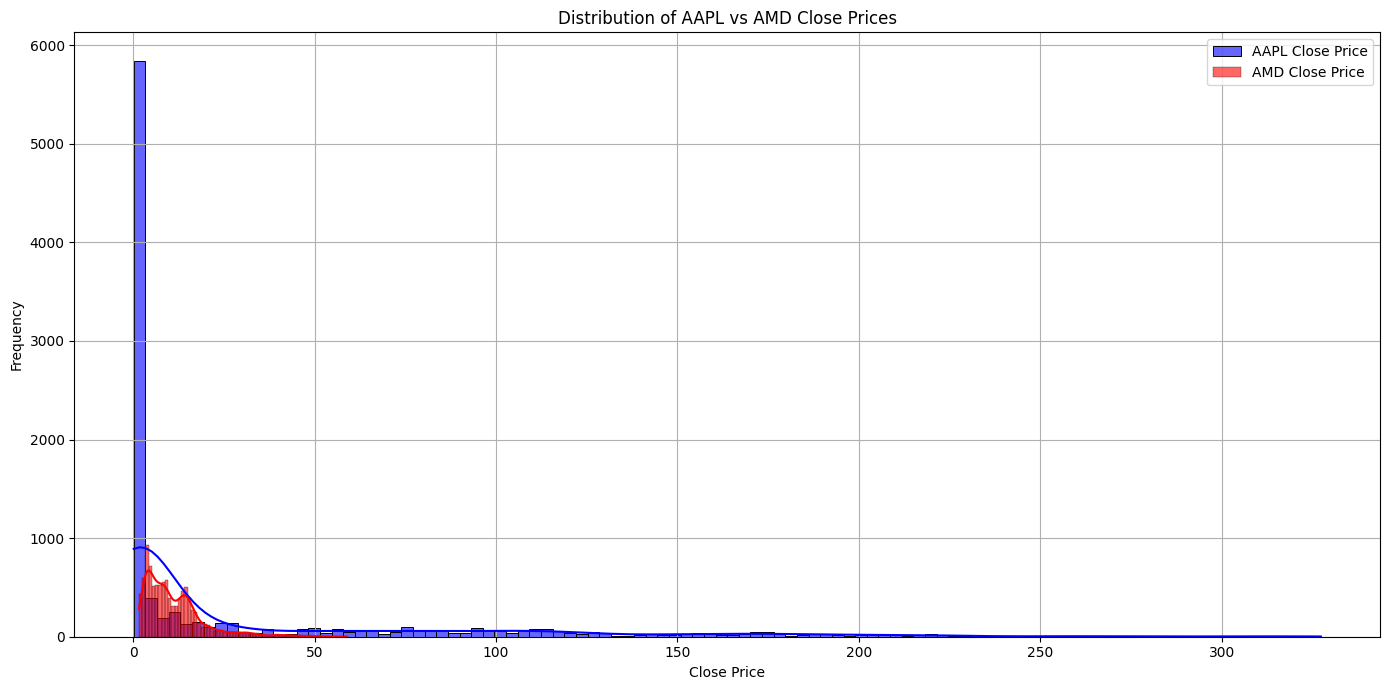

In [22]:
plt.figure(figsize=(14, 7))
sns.histplot(df_aapl['Close'], kde=True, color='blue', label='AAPL Close Price', alpha=0.6)
sns.histplot(df_amd['Close'], kde=True, color='red', label='AMD Close Price', alpha=0.6)

plt.title('Distribution of AAPL vs AMD Close Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Graph distribusi harga penutupan pasar menunjukan:

- Rentang Harga Dominan: dapat dilihat di kisaran harga mana saham tersebut paling sering berada. Jika grafik menumpuk di sisi kiri (harga rendah), artinya saham tersebut menghabiskan sebagian besar waktunya di harga rendah sebelum akhirnya tumbuh.

- Grafik menunjukan bahwa Apple memiliki skala distribusi harga yang lebih luas hingga mencapai $300+ dengan frekuensi perdagangan di ~5800.

- Garis kepadatan (KDE) membantu melihat bentuk umum dari distribusi tersebut. Apple memiliki ekor panjang ke arah kanan (right skewed) yang artinya saham tumbuh pesat dari harga kecil ke harga besar.

- Grafik menunjukan AMD memiliki frekuensi perdagangan yang lebih tenang dibanding Apple dengan dominasi frekuensi di `< $50` namun tetap menunjukan pertumbuhan valuasi hingga `> $50.`

#### A.2.4 Distribution of Trading Volume

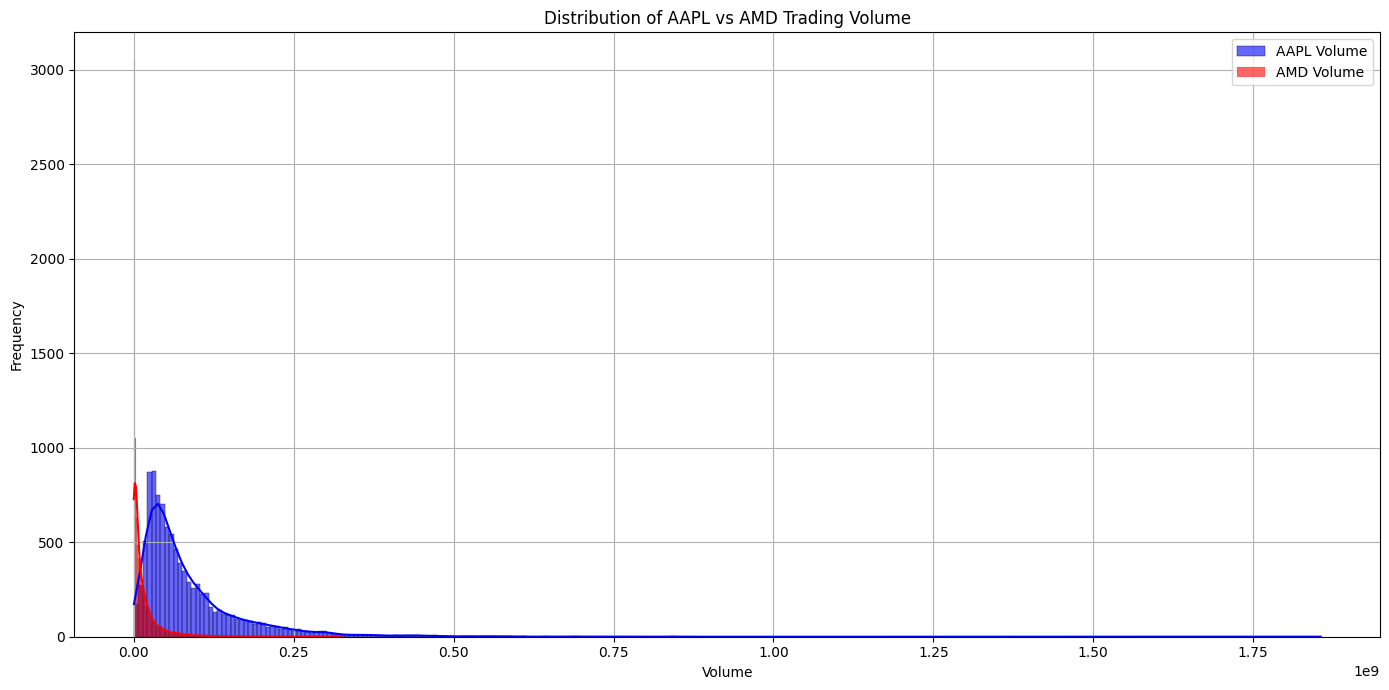

In [23]:
plt.figure(figsize=(14, 7))
sns.histplot(df_aapl['Volume'], kde=True, color='blue', label='AAPL Volume', alpha=0.6)
sns.histplot(df_amd['Volume'], kde=True, color='red', label='AMD Volume', alpha=0.6)

plt.title('Distribution of AAPL vs AMD Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Kurva jumlah perdagangan volume AAPL vs AMD menunjukan sebaran distribusi volume harian antar kedua emiten.

- Kedua emiten memiliki karakterisitik Right-skewed artinya sebagian besar waktu, volume perdagangan ini berada di angka relatif rendah hingga sedang. Ada juga beberapa hari dimana volume melonjak tinggi yang ditandai oleh ekor grafik memanjang ke kanan.

- Puncak Frekuensi: AMD memiliki puncak yang sangat tinggi melebihi All-Time-High Apple. Frekuensi kemunculan yang sedikit pada puncak tersebut menggambarkan perdagangan raksasa pada harga dan hari tertentu. Sedangkan AAPL memiliki puncak yang lebih landai dan bergeser sedikit ke kanan.

- Volume perdagangan AAPL (Biru) jauh lebih menyebar dan memiliki ekor yang sangat panjang ke arah kanan, bahkan hingga mendekati 1.75 * 10^9 (1,75 miliar saham). Ini menunjukkan bahwa AAPL secara signifikan memiliki likuiditas perdagangan yang jauh lebih masif dan sering mengalami hari-hari dengan lonjakan volume yang sangat ekstrem dibanding AMD.

### A.3 Splitting: 1 Year Test Set + (90/10) Train/Val Split
Strategi ini memastikan model diuji pada data yang benar-benar baru (1 tahun terakhir) sementara proses tuning dilakukan pada data sebelumnya.

AAPL - Train: 8689 rows
AAPL - Val: 966 rows
AAPL - Test: 254 rows (1 Year)


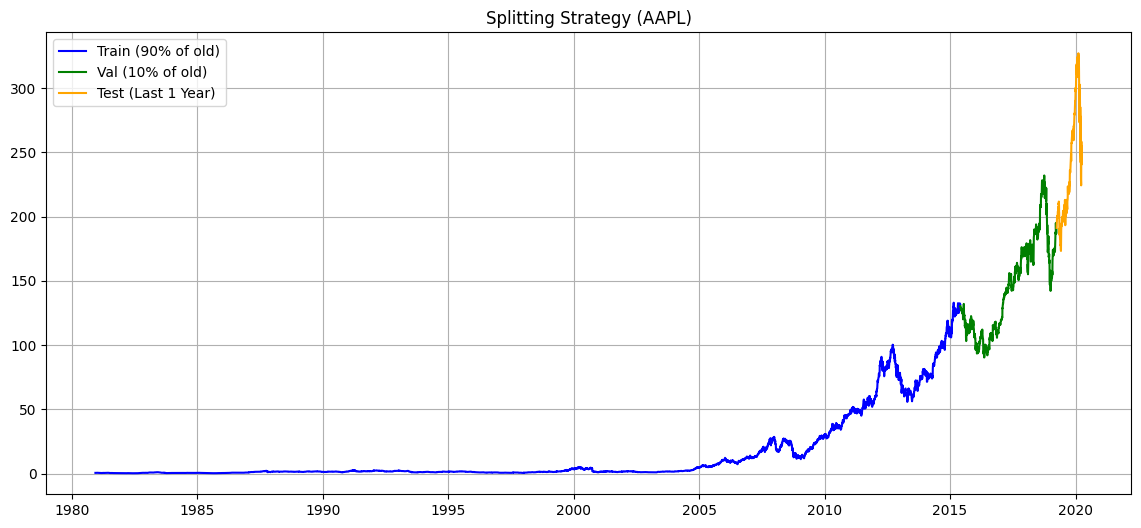

In [24]:
def split_time_series_advanced(df, train_val_ratio=0.9): #Fungsi splitting 90 / 10
    # 1. Pastikan terurut
    df = df.sort_values('Date').reset_index(drop=True)

    # 2. Ambil Test Set (1 Tahun Terakhir)
    last_date = df['Date'].max()
    cutoff_test = last_date - pd.DateOffset(years=1)

    train_val_df = df[df['Date'] < cutoff_test].reset_index(drop=True)
    test_df = df[df['Date'] >= cutoff_test].reset_index(drop=True)

    # 3. Split Train_Val menjadi Train dan Validation (90% | 10%)
    split_idx = int(len(train_val_df) * train_val_ratio)
    train_df = train_val_df.iloc[:split_idx]
    val_df = train_val_df.iloc[split_idx:]

    return train_df, val_df, test_df

# Implementasi untuk AAPL
aapl_train, aapl_val, aapl_test = split_time_series_advanced(df_aapl)

print(f"AAPL - Train: {len(aapl_train)} rows")
print(f"AAPL - Val: {len(aapl_val)} rows")
print(f"AAPL - Test: {len(aapl_test)} rows (1 Year)")

# Visualisasi
plt.figure(figsize=(14, 6))
plt.plot(aapl_train['Date'], aapl_train['Close'], label='Train (90% of old)', color='blue')
plt.plot(aapl_val['Date'], aapl_val['Close'], label='Val (10% of old)', color='green')
plt.plot(aapl_test['Date'], aapl_test['Close'], label='Test (Last 1 Year)', color='orange')
plt.title('Splitting Strategy (AAPL)')
plt.legend()
plt.grid(True)
plt.show()

AMD - Train: 8859 rows
AMD - Val: 985 rows
AMD - Test: 254 rows (1 Year)


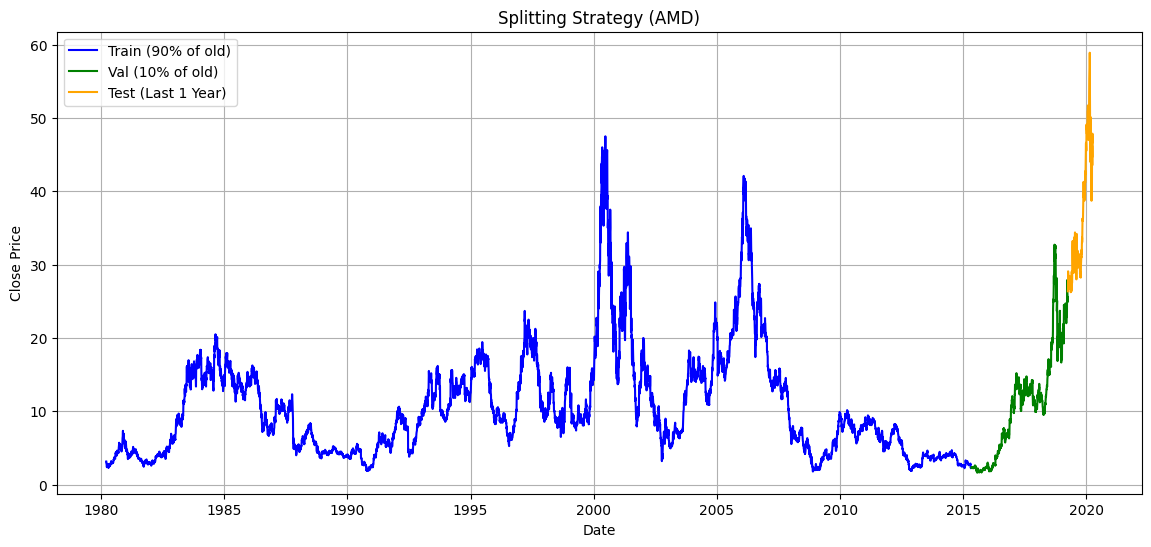

In [25]:
amd_train, amd_val, amd_test = split_time_series_advanced(df_amd)

print(f"AMD - Train: {len(amd_train)} rows")
print(f"AMD - Val: {len(amd_val)} rows")
print(f"AMD - Test: {len(amd_test)} rows (1 Year)")

# Visualisasi
plt.figure(figsize=(14, 6))
plt.plot(amd_train['Date'], amd_train['Close'], label='Train (90% of old)', color='blue')
plt.plot(amd_val['Date'], amd_val['Close'], label='Val (10% of old)', color='green')
plt.plot(amd_test['Date'], amd_test['Close'], label='Test (Last 1 Year)', color='orange')
plt.title('Splitting Strategy (AMD)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [26]:
class TimeSeriesDataset(Dataset): #Time series splitting untuk model DL LSTM
    def __init__(self, data, seq_length):
        self.data = torch.tensor(data, dtype=torch.float32)#Cast data torch
        self.seq_length = seq_length #berapa besar langkah waktu ke belakang

    def __len__(self):
        return len(self.data) - self.seq_length #Total sampel yang bisa dihasilkan data

    def __getitem__(self, idx):
        # Mengambil data sepanjang seq_length sebagai input (X), misal data dari hari 0 ke 29
        x = self.data[idx : idx + self.seq_length]
        # Mengambil 1 data setelahnya sebagai target (y), misal hari ke 30
        y = self.data[idx + self.seq_length]
        return x, y

# Parameter sequence (misal melihat 30 hari ke belakang)
SEQ_LENGTH = 30
BATCH_SIZE = 32

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit

In [28]:
#Buat scaler terpisah karena karakteristik harga pada AAPL dan AMD berbeda.
amd_scaler = MinMaxScaler(feature_range=(1, 2)) #Rentangkan harga di rentang 1 hingga 2
aapl_scaler = MinMaxScaler(feature_range=(1, 2)) #Rentangkan harga di rentang 1 hingga 2

# Scale the data for AAPL
# Fit scaler only on training data to prevent data leakage
scaled_aapl_train = aapl_scaler.fit_transform(aapl_train['Close'].values.reshape(-1, 1)) #Fit scaler hanya di train set untuk mencegah data leakage
scaled_aapl_val = aapl_scaler.transform(aapl_val['Close'].values.reshape(-1, 1))
scaled_aapl_test = aapl_scaler.transform(aapl_test['Close'].values.reshape(-1, 1))

# Inisialisasi Dataset & DataLoader for AAPL
aapl_train_dataset = TimeSeriesDataset(scaled_aapl_train, SEQ_LENGTH)
aapl_val_dataset = TimeSeriesDataset(scaled_aapl_val, SEQ_LENGTH)
aapl_test_dataset = TimeSeriesDataset(scaled_aapl_test, SEQ_LENGTH)

aapl_train_loader = DataLoader(aapl_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
aapl_val_loader = DataLoader(aapl_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
aapl_test_loader = DataLoader(aapl_test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [29]:
# Scale the data for AMD
scaled_amd_train = amd_scaler.fit_transform(amd_train['Close'].values.reshape(-1, 1)) #Fit scaler hanya di train set untuk mencegah data leakage
scaled_amd_val = amd_scaler.transform(amd_val['Close'].values.reshape(-1, 1))
scaled_amd_test = amd_scaler.transform(amd_test['Close'].values.reshape(-1, 1))

# Inisialisasi Dataset & DataLoader for AMD
amd_train_dataset = TimeSeriesDataset(scaled_amd_train, SEQ_LENGTH)
amd_val_dataset = TimeSeriesDataset(scaled_amd_val, SEQ_LENGTH)
amd_test_dataset = TimeSeriesDataset(scaled_amd_test, SEQ_LENGTH)

amd_train_loader = DataLoader(amd_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
amd_val_loader = DataLoader(amd_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
amd_test_loader = DataLoader(amd_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [30]:
print("Skala nilai train AAPL (max):", scaled_aapl_train.max())
print("Skala nilai test AAPL (max):", scaled_aapl_test.max())
print("Skala nilai train AMD (max):", scaled_amd_train.max())
print("Skala nilai test AMD:", scaled_amd_test.max())

Skala nilai train AAPL (max): 2.0
Skala nilai test AAPL (max): 3.46231016313636
Skala nilai train AMD (max): 2.0
Skala nilai test AMD: 2.2494529871768942


### B. Arsitektur Baseline LSTM (units = 50)

 dan layer akhir berupa node Perceptron dengan units=1. Activation function untuk LSTM menggunakan ReLU

#### B.1 Define Baseline Model

In [31]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(LSTMBaseline, self).__init__()

        # LSTM Layer (hidden_size = 50 units)
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            batch_first=True)

        # Linear layer / Perceptron (1 node akhir)
        self.fc = nn.Linear(in_features=hidden_size, out_features=output_size)

        # Activation ReLU
        self.relu = nn.ReLU()

    def forward(self, x):
        # Output LSTM berdimensi (batch_size, seq_length, hidden_size)
        out, _ = self.lstm(x)

        # Ambil output dari time-step terakhir
        out = out[:, -1, :]

        # Lewatkan ke Perceptron akhir dan ReLU
        out = self.fc(out)
        out = self.relu(out)
        return out


input_features = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#initialize model
base_model = LSTMBaseline(input_size=1, hidden_size=50, output_size=1).to(device)

#Paksa bias awal model agar tidak dekat dengan 0, untuk menghindari
#kelemahan ReLU saat bobot menjadi 0 dan tidak ada update samsek.
torch.nn.init.constant_(base_model.fc.bias, 3.0)
print(base_model)

LSTMBaseline(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
  (relu): ReLU()
)


#### B.2 Define Optimizer

In [32]:
base_optimizer = optim.Adam(base_model.parameters(), lr = 0.01)
criterion = nn.MSELoss()
#Gunakan MSELoss karena memaksa model memprediksi nilai kondisional mean pada data target yang bersifat stokastik
#(memiliki banyak noise dan fluktuasi acak)

#### B.3 Define Training Loop Function

In [33]:
#Muat loader tiap data train, test, val untuk dipelajari model
train_loader_list = [aapl_train_loader, amd_train_loader]
test_loader_list = [aapl_test_loader, amd_test_loader]
val_loader_list = [aapl_val_loader, amd_val_loader]

In [34]:
import copy

def train_model(model, optimizers, EPOCHS):
  aapl_train_loss_history = []
  aapl_val_loss_history = []

  amd_train_loss_history = []
  amd_val_loss_history = []

  # --- INISIALISASI CHECKPOINT ---
  best_combined_val_loss = float('inf')
  best_model_wts = copy.deepcopy(model.state_dict()) # Menyimpan bobot awal model
  best_epoch = 1

  for epoch in range(1, EPOCHS + 1):
      # --- TRAINING PHASE ---
      model.train() # Set model ke mode training

      aapl_train_epoch_loss = 0.0
      amd_train_epoch_loss = 0.0
      aapl_train_epoch_samples = 0
      amd_train_epoch_samples = 0

      for loader in train_loader_list:
          for batch_x, batch_y in loader:
              # Pindahkan data ke device cpu/cuda
              batch_x, batch_y = batch_x.to(device), batch_y.to(device)

              # Reset beban gradient untuk tiap perhitungan batch
              optimizers.zero_grad()

              # Forward pass (Prediksi)
              predictions = model(batch_x)
              loss = criterion(predictions, batch_y)

              # Backward pass (Hitung Gradien)
              loss.backward()

              # Koreksi bobot menggunakan optimizer method
              optimizers.step()

              # Kalkulasi Akumulasi loss dikali jumlah sampel dalam batch saat ini
              if loader is aapl_train_loader:
                  aapl_train_epoch_loss += loss.item() * batch_x.size(0)
                  aapl_train_epoch_samples += batch_x.size(0)
              elif loader is amd_train_loader:
                  amd_train_epoch_loss += loss.item() * batch_x.size(0)
                  amd_train_epoch_samples += batch_x.size(0)

      # Simpan rata-rata loss untuk tiap emiten
      if aapl_train_epoch_samples > 0:
          aapl_train_loss_history.append(aapl_train_epoch_loss / aapl_train_epoch_samples)
      else:
          aapl_train_loss_history.append(0.0)

      if amd_train_epoch_samples > 0:
          amd_train_loss_history.append(amd_train_epoch_loss / amd_train_epoch_samples)
      else:
          amd_train_loss_history.append(0.0)

      # --- EVALUATION PHASE ---
      model.eval() # Set model ke mode evaluasi

      aapl_val_epoch_loss = 0.0
      amd_val_epoch_loss = 0.0
      aapl_val_epoch_samples = 0
      amd_val_epoch_samples = 0

      with torch.no_grad(): # Matikan pencatatan gradien untuk hemat memori
          for loader in val_loader_list:
              for batch_x, batch_y in loader:
                  batch_x, batch_y = batch_x.to(device), batch_y.to(device)

                  predictions = model(batch_x)
                  loss = criterion(predictions, batch_y)

                  # Kalkulasi Akumulasi loss dikali jumlah sampel dalam batch saat ini
                  if loader is aapl_val_loader:
                      aapl_val_epoch_loss += loss.item() * batch_x.size(0)
                      aapl_val_epoch_samples += batch_x.size(0)
                  elif loader is amd_val_loader:
                      amd_val_epoch_loss += loss.item() * batch_x.size(0)
                      amd_val_epoch_samples += batch_x.size(0)

      # Simpan rata-rata loss untuk tiap emiten
      current_aapl_val_loss = aapl_val_epoch_loss / aapl_val_epoch_samples if aapl_val_epoch_samples > 0 else 0.0
      current_amd_val_loss = amd_val_epoch_loss / amd_val_epoch_samples if amd_val_epoch_samples > 0 else 0.0

      aapl_val_loss_history.append(current_aapl_val_loss)
      amd_val_loss_history.append(current_amd_val_loss)

      # Menghitung rata-rata loss gabungan (AAPL + AMD) pada epoch berjalan
      total_val_loss = aapl_val_epoch_loss + amd_val_epoch_loss
      total_val_samples = aapl_val_epoch_samples + amd_val_epoch_samples
      current_combined_val_loss = total_val_loss / total_val_samples if total_val_samples > 0 else float('inf')

      # Checkpoint Model berdasarkan val_loss kombinasi terbaik
      if current_combined_val_loss < best_combined_val_loss:
          best_combined_val_loss = current_combined_val_loss
          best_model_wts = copy.deepcopy(model.state_dict())
          best_epoch = epoch

      #debug deskripsi per epoch
      print(f"Epoch [{epoch}/{EPOCHS}] | AAPL Train Loss: {aapl_train_loss_history[-1]:.6f} | AAPL Val Loss: {aapl_val_loss_history[-1]:.6f} | AMD Train Loss: {amd_train_loss_history[-1]:.6f} | AMD Val Loss: {amd_val_loss_history[-1]:.6f}")

  # Load model terbaik setelah training loop
  print("\n------------------------------------------------------------")
  print(f"Training Selesai! Memuat Model Terbaik dari Epoch ke-{best_epoch}")
  print(f"Nilai Combined Val Loss Terbaik: {best_combined_val_loss:.6f}")
  print("------------------------------------------------------------")

  # Mengembalikan bobot model ke kondisi terbaiknya
  model.load_state_dict(best_model_wts)

  return aapl_train_loss_history, aapl_val_loss_history, amd_train_loss_history, amd_val_loss_history

#### B.4 Training Baseline

In [35]:
EPOCHS = 10
aapl_train_loss_history, aapl_val_loss_history, amd_train_loss_history, amd_val_loss_history = train_model(base_model, base_optimizer,  EPOCHS)

Epoch [1/10] | AAPL Train Loss: 0.062396 | AAPL Val Loss: 0.040620 | AMD Train Loss: 0.000554 | AMD Val Loss: 0.000711
Epoch [2/10] | AAPL Train Loss: 0.000083 | AAPL Val Loss: 0.024784 | AMD Train Loss: 0.000367 | AMD Val Loss: 0.000353
Epoch [3/10] | AAPL Train Loss: 0.000098 | AAPL Val Loss: 0.016161 | AMD Train Loss: 0.000323 | AMD Val Loss: 0.000248
Epoch [4/10] | AAPL Train Loss: 0.000067 | AAPL Val Loss: 0.009338 | AMD Train Loss: 0.000402 | AMD Val Loss: 0.000358
Epoch [5/10] | AAPL Train Loss: 0.000045 | AAPL Val Loss: 0.007151 | AMD Train Loss: 0.000325 | AMD Val Loss: 0.000572
Epoch [6/10] | AAPL Train Loss: 0.000052 | AAPL Val Loss: 0.007368 | AMD Train Loss: 0.000316 | AMD Val Loss: 0.000464
Epoch [7/10] | AAPL Train Loss: 0.000060 | AAPL Val Loss: 0.007918 | AMD Train Loss: 0.000322 | AMD Val Loss: 0.000372
Epoch [8/10] | AAPL Train Loss: 0.000061 | AAPL Val Loss: 0.004070 | AMD Train Loss: 0.000265 | AMD Val Loss: 0.000204
Epoch [9/10] | AAPL Train Loss: 0.000036 | AAPL 



$f(x) = max(0, x)$ dengan karakteristik turunan (gradien):
$$f'(x) = \begin{cases} 1, \text{jika } x > 0 \\ 0,  \text{jika } x \le 0 \end{cases}$$



In [ ]:
base_model.eval()
aapl_predictions = []
aapl_actuals = []

amd_predictions = []
amd_actuals = []

with torch.no_grad():
    for loader in val_loader_list:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            preds = base_model(batch_x)
            
            if loader is aapl_val_loader:
                aapl_predictions.append(preds.cpu().numpy())
                aapl_actuals.append(batch_y.cpu().numpy()) 
            elif loader is amd_val_loader:
                amd_predictions.append(preds.cpu().numpy())
                amd_actuals.append(batch_y.cpu().numpy())

# --- EVALUASI EMITEN AAPL ---
if len(aapl_predictions) > 0:
    aapl_predictions = np.vstack(aapl_predictions)
    aapl_actuals = np.vstack(aapl_actuals)

    #muat scaler dan inverse kembali ke rentang nilai asli
    aapl_actual_prices = aapl_scaler.inverse_transform(aapl_actuals)
    aapl_predicted_prices = aapl_scaler.inverse_transform(aapl_predictions)

    # hitung metricnya
    aapl_mse = mean_squared_error(aapl_actual_prices, aapl_predicted_prices)
    aapl_mae = mean_absolute_error(aapl_actual_prices, aapl_predicted_prices)
    aapl_mape = mean_absolute_percentage_error(aapl_actual_prices, aapl_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AAPL [Base - Validation]:")
    print(f"Mean Squared Error (MSE): {aapl_mse:.4f}")
    print(f"Mean Absolute Error (MAE): {aapl_mae:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {aapl_mape:.4f}")

# --- EVALUASI EMITEN AMD ---
if len(amd_predictions) > 0:
    amd_predictions = np.vstack(amd_predictions)
    amd_actuals = np.vstack(amd_actuals)

    # muat scaler dan inverse kembali ke rentang nilai asli
    amd_actual_prices = amd_scaler.inverse_transform(amd_actuals)
    amd_predicted_prices = amd_scaler.inverse_transform(amd_predictions)

    # hitung metricnya
    amd_mse = mean_squared_error(amd_actual_prices, amd_predicted_prices)
    amd_mae = mean_absolute_error(amd_actual_prices, amd_predicted_prices)
    amd_mape = mean_absolute_percentage_error(amd_actual_prices, amd_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AMD [Base - Validation]:")
    print(f"Mean Squared Error (MSE): {amd_mse:.4f}")
    print(f"Mean Absolute Error (MAE): {amd_mae:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {amd_mape:.4f}")


Hasil Evaluasi Harga Asli - AAPL [Base - Validation]:
Mean Squared Error (MSE): 36.4242
Mean Absolute Error (MAE): 3.8561
Mean Absolute Percentage Error (MAPE): 0.0237

Hasil Evaluasi Harga Asli - AMD [Base - Validation]:
Mean Squared Error (MSE): 1.0972
Mean Absolute Error (MAE): 0.9434
Mean Absolute Percentage Error (MAPE): 0.1737


#### B.5 Metric Plot

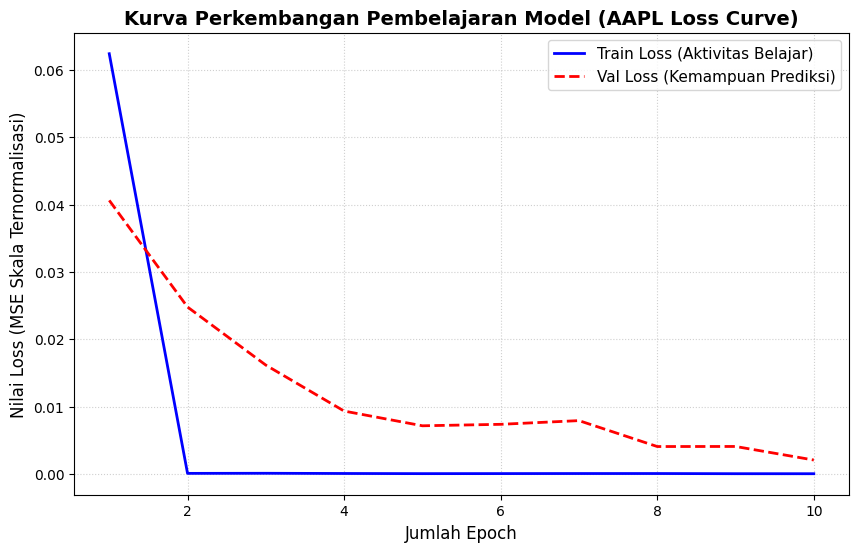

In [37]:
plt.figure(figsize=(10, 6))

# Plot kurva train loss dan test loss
plt.plot(range(1, EPOCHS + 1), aapl_train_loss_history, label='Train Loss (Aktivitas Belajar)', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS + 1), aapl_val_loss_history, label='Val Loss (Kemampuan Prediksi)', color='red', linestyle='--', linewidth=2)

# Menambahkan elemen informasi pada grafik
plt.title('Kurva Perkembangan Pembelajaran Model (AAPL Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Epoch', fontsize=12)
plt.ylabel('Nilai Loss (MSE Skala Ternormalisasi)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Menampilkan grafik
plt.show()

Kurva Loss menunjukan AAPL loss yang sangat baik dimana garis biru turun tajam pada epoch ke 2 dan langsung mendatar stabil di 0.0001 disertai test loss yang mengikuti tren penurun namun lebih halus dan stabil hingga epoch ke 10. Tidak ada indikasi overfitting

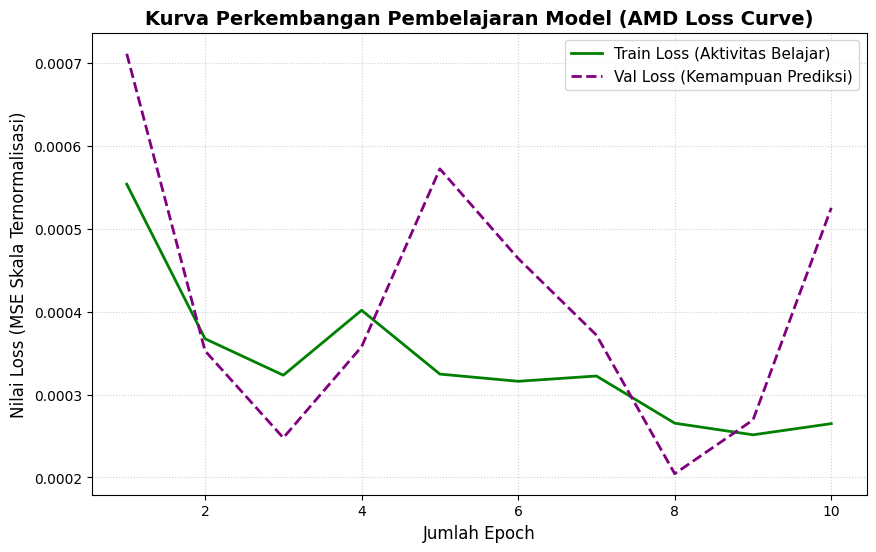

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), amd_train_loss_history, label='Train Loss (Aktivitas Belajar)', color='green', linewidth=2)
plt.plot(range(1, EPOCHS + 1), amd_val_loss_history, label='Val Loss (Kemampuan Prediksi)', color='purple', linestyle='--', linewidth=2)
plt.title('Kurva Perkembangan Pembelajaran Model (AMD Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Epoch', fontsize=12)
plt.ylabel('Nilai Loss (MSE Skala Ternormalisasi)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Menampilkan grafik
plt.show()

Kurva AMD jauh lebih kecil, kurvanya terlihat bergerak naik-turun fluktuatif yang wajar akibat data emiten yang lebih volatil. Menariknya model lebih pintar memprediksi data test dibanding train pada epoch 3-4 dan juga 6-10 namun gejolak terhitung sangat wajar mengingat skala zoom kurva di 0.0006 hingga 0.0001. Ini menunjukan kemampuan generalisasi model yang sangat baik.

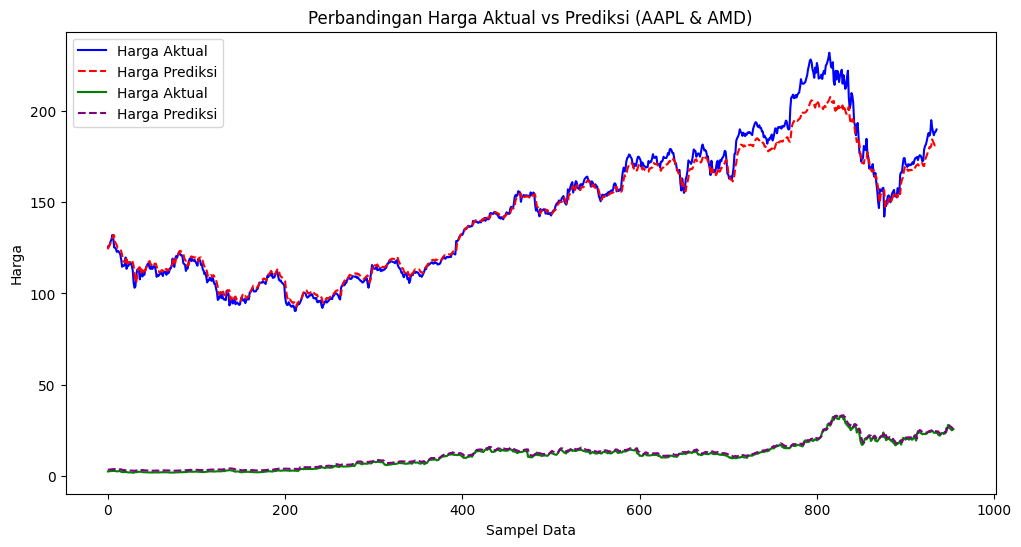

In [39]:
plt.figure(figsize=(12,6))
plt.plot(aapl_actual_prices, label='Harga Aktual', color='blue')
plt.plot(aapl_predicted_prices, label='Harga Prediksi', color='red', linestyle='--')

plt.plot(amd_actual_prices, label='Harga Aktual', color='green')
plt.plot(amd_predicted_prices, label='Harga Prediksi', color='purple', linestyle='--')

plt.title('Perbandingan Harga Aktual vs Prediksi (AAPL & AMD)')
plt.xlabel('Sampel Data')
plt.ylabel('Harga')
plt.legend()
plt.show()

Kurva atas adalah pergerakan harga asli vs prediksi dari emiten AAPL dengan volatilitas tinggi.

- Model berhasil menangkap tren pergerakan harga jangka panjang (uptrend maupun downtrend) dengan sangat presisi.

- Pada area volatilitas tinggi (sekitar sampel data 800 ke atas), terdapat sedikit celah (gap) di mana harga prediksi sedikit lebih rendah dari harga aktual, namun model tetap berhasil meniru pola lekukan naik-turunnya secara akurat tanpa mengalami lagting (keterlambatan arah) yang parah.

Kurva bawah adalah pergerakan harga asli vs prediksi dari emiten AMD dengan harga nominal yang lebih rendah:

- Pada saham dengan nominal harga lebih rendah (berada di kisaran di bawah 50), garis merah dan biru terlihat hampir berhimpitan sempurna di sepanjang sampel data. Ini menandakan tingkat error yang sangat minimal dengan prediksi pergerakan harga yang sangat baik.

### C. Modifikasi Arsitektur

pada nomor 1c untuk mendapatkan unjuk kerja yang optimal (kalian dapat menambahkan atau mengurangi arsitektur tersebut, atau mengganti hyperparameter, atau menggunakan tuning pada hyperparameter). Jelaskan alasan kalian untuk menggunakan pendekatan yang kalian pilih.

#### C.1 Define Modified Model

Untuk memperbaik kinerja baseline model dan mencegah overfitting:
- Tambahkan dropout 0.2
- inisiasi bias 3.0
- tambahkan l2_regularizations weight decay: 1e-5

In [40]:
class LSTM_Modified(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1, dropout_prob=0.2):
        super(LSTM_Modified, self).__init__()

        # LSTM Layer (hidden_size = 50 units)
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            batch_first=True)

        # Dropout mencegah overfitting
        self.dropout = nn.Dropout(p=dropout_prob)

        # Linear layer / Perceptron (1 node akhir)
        self.fc = nn.Linear(in_features=hidden_size, out_features=output_size)

        # Aktivasi ReLU
        self.relu = nn.ReLU()

    def forward(self, x):
        # Output dari lstm berdimensi (batch_size, seq_length, hidden_size)
        out, _ = self.lstm(x)

        # Ambil output dari time-step terakhir
        out = out[:, -1, :]

        # Dropout sebelum masuk ke perceptron akhir
        out = self.dropout(out)

        # Lewatkan ke Perceptron akhir dan ReLU
        out = self.fc(out)
        out = self.relu(out)
        return out

# 1. Buat objek model baru dengan dropout 0.2
modified_model = LSTM_Modified(input_size=1, hidden_size=50, output_size=1, dropout_prob=0.2).to(device)

# 2. Initiate bias untuk menghindari kelemahan ReLU pada LSTM
torch.nn.init.constant_(modified_model.fc.bias, 3.0)

Parameter containing:
tensor([3.], requires_grad=True)

#### C.2 Define Optimizer

In [41]:
# Inisiasi ulang model dan optimizer
# Ditambahkan weight decay untuk L2_regularisasi yang mencegah overfitting
modified_optimizer = optim.Adam(modified_model.parameters(), lr=0.001, weight_decay=1e-5)

In [42]:
EPOCHS = 30
aapl_train_loss_history, aapl_val_loss_history, amd_train_loss_history, amd_val_loss_history = train_model(modified_model, modified_optimizer, EPOCHS)

Epoch [1/30] | AAPL Train Loss: 0.337560 | AAPL Val Loss: 0.228823 | AMD Train Loss: 0.041829 | AMD Val Loss: 0.007976
Epoch [2/30] | AAPL Train Loss: 0.021652 | AAPL Val Loss: 0.135026 | AMD Train Loss: 0.019427 | AMD Val Loss: 0.004767
Epoch [3/30] | AAPL Train Loss: 0.019480 | AAPL Val Loss: 0.094059 | AMD Train Loss: 0.018128 | AMD Val Loss: 0.001605
Epoch [4/30] | AAPL Train Loss: 0.018161 | AAPL Val Loss: 0.078281 | AMD Train Loss: 0.017815 | AMD Val Loss: 0.004949
Epoch [5/30] | AAPL Train Loss: 0.016792 | AAPL Val Loss: 0.064827 | AMD Train Loss: 0.015301 | AMD Val Loss: 0.001977
Epoch [6/30] | AAPL Train Loss: 0.015693 | AAPL Val Loss: 0.059775 | AMD Train Loss: 0.014212 | AMD Val Loss: 0.001619
Epoch [7/30] | AAPL Train Loss: 0.014680 | AAPL Val Loss: 0.059233 | AMD Train Loss: 0.012932 | AMD Val Loss: 0.001008
Epoch [8/30] | AAPL Train Loss: 0.013219 | AAPL Val Loss: 0.039416 | AMD Train Loss: 0.011714 | AMD Val Loss: 0.001440
Epoch [9/30] | AAPL Train Loss: 0.012243 | AAPL 

#### C.3 Modified Evaluation

In [43]:
modified_model.eval()
aapl_predictions = []
aapl_actuals = []

amd_predictions = []
amd_actuals = []

with torch.no_grad():
    for loader in val_loader_list:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            preds = modified_model(batch_x)

            if loader is aapl_val_loader:
                aapl_predictions.append(preds.cpu().numpy())
                aapl_actuals.append(batch_y.cpu().numpy())
            elif loader is amd_val_loader:
                amd_predictions.append(preds.cpu().numpy())
                amd_actuals.append(batch_y.cpu().numpy())

# EVALUASI EMITEN AAPL
if len(aapl_predictions) > 0:
    aapl_predictions = np.vstack(aapl_predictions)
    aapl_actuals = np.vstack(aapl_actuals)

    aapl_actual_prices = aapl_scaler.inverse_transform(aapl_actuals)
    aapl_predicted_prices = aapl_scaler.inverse_transform(aapl_predictions)

    mod_aapl_mse = mean_squared_error(aapl_actual_prices, aapl_predicted_prices)
    mod_aapl_mae = mean_absolute_error(aapl_actual_prices, aapl_predicted_prices)
    mod_aapl_mape = mean_absolute_percentage_error(aapl_actual_prices, aapl_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AAPL (Mod - Validation):")
    print(f"Mean Squared Error (MSE): {mod_aapl_mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mod_aapl_mae:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mod_aapl_mape:.4f}")

# EVALUASI EMITEN AMD
if len(amd_predictions) > 0:
    amd_predictions = np.vstack(amd_predictions)
    amd_actuals = np.vstack(amd_actuals)

    amd_actual_prices = amd_scaler.inverse_transform(amd_actuals)
    amd_predicted_prices = amd_scaler.inverse_transform(amd_predictions)

    mod_amd_mse = mean_squared_error(amd_actual_prices, amd_predicted_prices)
    mod_amd_mae = mean_absolute_error(amd_actual_prices, amd_predicted_prices)
    mod_amd_mape = mean_absolute_percentage_error(amd_actual_prices, amd_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AMD [Mod - Validation]:")
    print(f"Mean Squared Error (MSE): {mod_amd_mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mod_amd_mae:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mod_amd_mape:.4f}")


Hasil Evaluasi Harga Asli - AAPL (Mod - Validation):
Mean Squared Error (MSE): 19.3423
Mean Absolute Error (MAE): 3.0880
Mean Absolute Percentage Error (MAPE): 0.0198

Hasil Evaluasi Harga Asli - AMD [Mod - Validation]:
Mean Squared Error (MSE): 0.6119
Mean Absolute Error (MAE): 0.5847
Mean Absolute Percentage Error (MAPE): 0.0977


#### C.4 Metric Plot

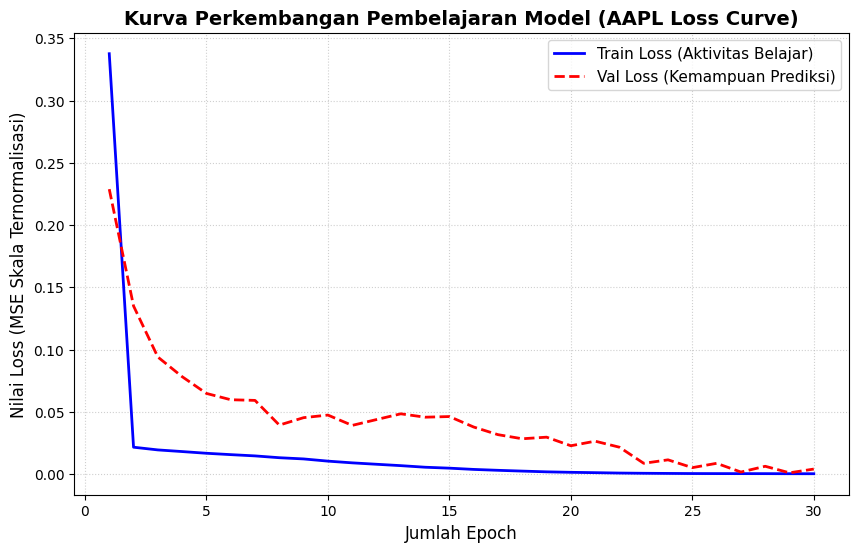

In [44]:
plt.figure(figsize=(10, 6))

# Plot kurva train loss dan val loss
plt.plot(range(1, EPOCHS + 1), aapl_train_loss_history, label='Train Loss (Aktivitas Belajar)', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS + 1), aapl_val_loss_history, label='Val Loss (Kemampuan Prediksi)', color='red', linestyle='--', linewidth=2)

# Menambahkan elemen informasi pada grafik
plt.title('Kurva Perkembangan Pembelajaran Model (AAPL Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Epoch', fontsize=12)
plt.ylabel('Nilai Loss (MSE Skala Ternormalisasi)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Menampilkan grafik
plt.show()

Pada model sebelumnya (10 epoch), kurva Test Loss terpotong saat masih dalam tren menurun tajam. Dengan 30 epoch, kita bisa melihat gambaran utuh. Meskipun sempat ada fluktuasi kecil (puncak kecil di sekitar epoch 15 dan 28), Test Loss (merah) berhasil menyentuh titik terendah mendekati 0.00 pada epoch 30.

Model tidak mengalami overfitting meskipun dilatih 3x lebih lama. Garis Test Loss mengarah rapat menuju Train Loss yang mengindikasikan konvergensi optimal.

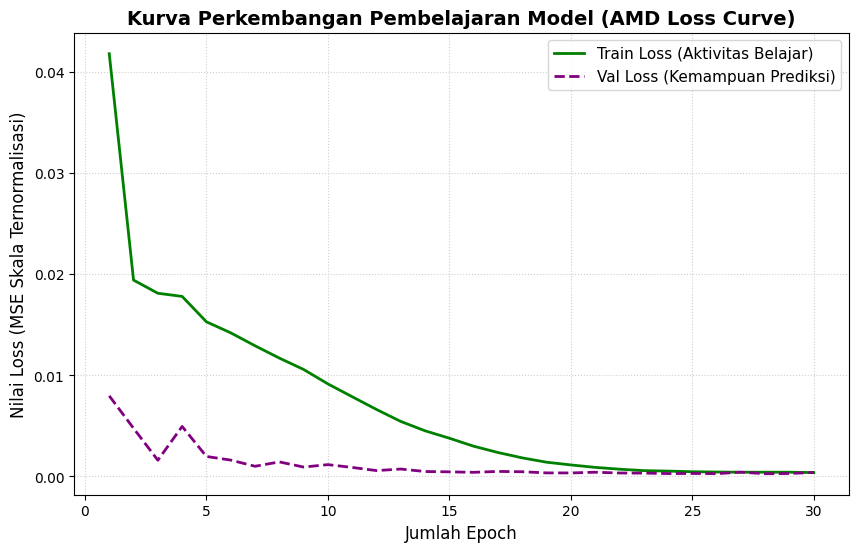

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), amd_train_loss_history, label='Train Loss (Aktivitas Belajar)', color='green', linewidth=2)
plt.plot(range(1, EPOCHS + 1), amd_val_loss_history, label='Val Loss (Kemampuan Prediksi)', color='purple', linestyle='--', linewidth=2)
plt.title('Kurva Perkembangan Pembelajaran Model (AMD Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Epoch', fontsize=12)
plt.ylabel('Nilai Loss (MSE Skala Ternormalisasi)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Menampilkan grafik
plt.show()

Peningkatan kinerja loss pada emiten AMD mengalami peningkatan besar dari baseline. Versi modifikasi kurva Train Loss (hijau) meluncur turun dengan sangat mulus, dan uniknya test loss juga ikut turun ke bawah 0.005 sejak epoch ke-2 dan konsisten stabil hingga epoch terakhir.

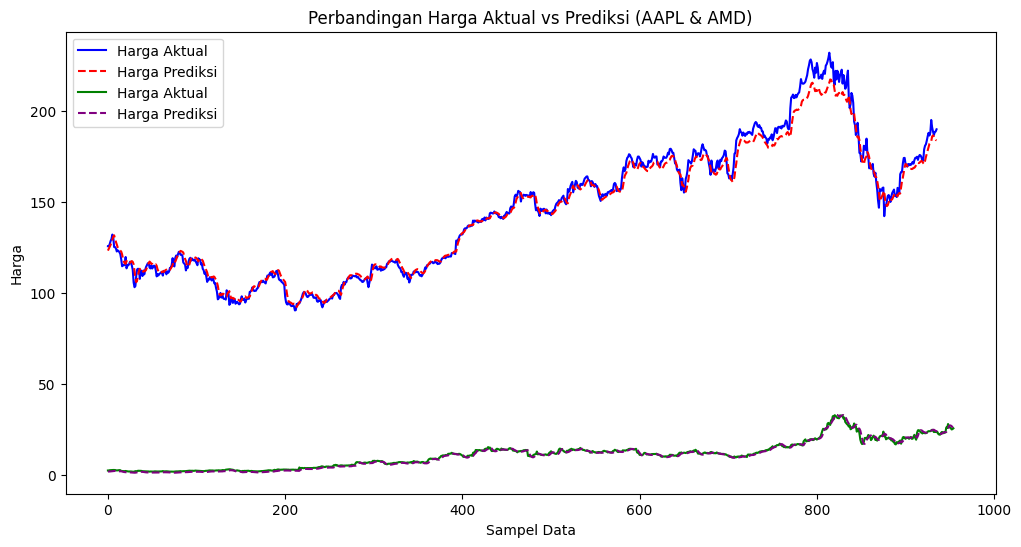

In [46]:
plt.figure(figsize=(12,6))
plt.plot(aapl_actual_prices, label='Harga Aktual', color='blue')
plt.plot(aapl_predicted_prices, label='Harga Prediksi', color='red', linestyle='--')

plt.plot(amd_actual_prices, label='Harga Aktual', color='green')
plt.plot(amd_predicted_prices, label='Harga Prediksi', color='purple', linestyle='--')

plt.title('Perbandingan Harga Aktual vs Prediksi (AAPL & AMD)')
plt.xlabel('Sampel Data')
plt.ylabel('Harga')
plt.legend()
plt.show()

Peningkatan kinerja baik pada kurva loss pada AAPL dan AMD membuat perubahan prediksi aktual vs prediksi tetap sangat akurat.

- Garis prediksi (merah putus-putus) pada saham AAPL tetap mampu menempel ketat pada harga aktual (biru), dan pada saham AMD, kedua garis tersebut berhimpitan hampir tanpa celah.

- Ini menunjukkan bahwa model versi modifikasi ini mencapai performa tingkat akurasi yang sama tingginya dengan model pertama, tetapi dengan tingkat kepastian (stabilitas) sistem yang jauh lebih aman.

#### C.5 Summary Metric

In [51]:
data_perbandingan = {
    'Model (Validation)': ['Base Model', 'Base Model', 'Modified Model', 'Modified Model'],
    'Asset': ['AAPL', 'AMD', 'AAPL', 'AMD'],
    'MSE': [aapl_mse, amd_mse, mod_aapl_mse, mod_amd_mse],
    'MAE': [aapl_mae, amd_mae, mod_aapl_mae, mod_amd_mae],
    'MAPE': [aapl_mape, amd_mape, mod_aapl_mape, mod_amd_mape]
}

df_hasil = pd.DataFrame(data_perbandingan)

# 3. Menampilkan DataFrame dengan pembulatan 4 angka di belakang koma agar rapi
df_hasil_val = df_hasil.round(4)
df_hasil_val

,Model (Validation),Asset,MSE,MAE,MAPE
0,Base Model,AAPL,36.4242,3.8561,0.0237
1,Base Model,AMD,1.0972,0.9434,0.1737
2,Modified Model,AAPL,19.3423,3.0880,0.0198
3,Modified Model,AMD,0.6119,0.5847,0.0977


### D. Evaluasi Kedua Model Arsitektur dengan Test Set

#### D.1 Base Model Comparison with test set

In [ ]:
base_model.eval()
aapl_predictions = []
aapl_actuals = []

amd_predictions = []
amd_actuals = []

from sklearn.metrics import root_mean_squared_error
with torch.no_grad():
    for loader in test_loader_list:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            preds = base_model(batch_x)

            if loader is aapl_test_loader:
                aapl_predictions.append(preds.cpu().numpy())
                aapl_actuals.append(batch_y.cpu().numpy())
            elif loader is amd_test_loader:
                amd_predictions.append(preds.cpu().numpy())
                amd_actuals.append(batch_y.cpu().numpy())

# --- EVALUASI EMITEN AAPL ---
if len(aapl_predictions) > 0:
    aapl_predictions = np.vstack(aapl_predictions)
    aapl_actuals = np.vstack(aapl_actuals)

    aapl_actual_prices = aapl_scaler.inverse_transform(aapl_actuals)
    aapl_predicted_prices = aapl_scaler.inverse_transform(aapl_predictions)

    base_aapl_rmse_test = root_mean_squared_error(aapl_actual_prices, aapl_predicted_prices)
    base_aapl_mse_test = mean_squared_error(aapl_actual_prices, aapl_predicted_prices)
    base_aapl_mae_test = mean_absolute_error(aapl_actual_prices, aapl_predicted_prices)
    base_aapl_mape_test = mean_absolute_percentage_error(aapl_actual_prices, aapl_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AAPL [Test-Set]:")
    print(f"Root Mean Squared Error (MSE): {base_aapl_rmse_test:.4f}")
    print(f"Mean Squared Error (MSE): {base_aapl_mse_test:.4f}")
    print(f"Mean Absolute Error (MAE): {base_aapl_mae_test:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {base_aapl_mape_test:.4f}")

# --- EVALUASI EMITEN AMD ---
if len(amd_predictions) > 0:
    amd_predictions = np.vstack(amd_predictions)
    amd_actuals = np.vstack(amd_actuals)

    amd_actual_prices = amd_scaler.inverse_transform(amd_actuals)
    amd_predicted_prices = amd_scaler.inverse_transform(amd_predictions)

    base_amd_rmse_test = root_mean_squared_error(amd_actual_prices, amd_predicted_prices)
    base_amd_mse_test = mean_squared_error(amd_actual_prices, amd_predicted_prices)
    base_amd_mae_test = mean_absolute_error(amd_actual_prices, amd_predicted_prices)
    base_amd_mape_test = mean_absolute_percentage_error(amd_actual_prices, amd_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AMD [Test-Set]:")
    print(f"Root Mean Squared Error (MSE): {base_amd_rmse_test:.4f}")
    print(f"Mean Squared Error (MSE): {base_amd_mse_test:.4f}")
    print(f"Mean Absolute Error (MAE): {base_amd_mae_test:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {base_amd_mape_test:.4f}")


Hasil Evaluasi Harga Asli - AAPL [Test-Set]:
Root Mean Squared Error (MSE): 41.5383
Mean Squared Error (MSE): 1725.4319
Mean Absolute Error (MAE): 33.4483
Mean Absolute Percentage Error (MAPE): 0.1243

Hasil Evaluasi Harga Asli - AMD [Test-Set]:
Root Mean Squared Error (MSE): 1.5106
Mean Squared Error (MSE): 2.2820
Mean Absolute Error (MAE): 1.0608
Mean Absolute Percentage Error (MAPE): 0.0287


#### D.2 Modified Model

In [ ]:
modified_model.eval()
aapl_predictions = []
aapl_actuals = []

amd_predictions = []
amd_actuals = []

with torch.no_grad():
    for loader in test_loader_list:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            preds = modified_model(batch_x)

            if loader is aapl_test_loader:
                aapl_predictions.append(preds.cpu().numpy())
                aapl_actuals.append(batch_y.cpu().numpy()) 
            elif loader is amd_test_loader:
                amd_predictions.append(preds.cpu().numpy())
                amd_actuals.append(batch_y.cpu().numpy())

# --- EVALUASI EMITEN AAPL ---
if len(aapl_predictions) > 0:
    aapl_predictions = np.vstack(aapl_predictions)
    aapl_actuals = np.vstack(aapl_actuals)

    aapl_actual_prices = aapl_scaler.inverse_transform(aapl_actuals)
    aapl_predicted_prices = aapl_scaler.inverse_transform(aapl_predictions)

    mod_aapl_rmse_test = root_mean_squared_error(aapl_actual_prices, aapl_predicted_prices)
    mod_aapl_mse_test = mean_squared_error(aapl_actual_prices, aapl_predicted_prices)
    mod_aapl_mae_test = mean_absolute_error(aapl_actual_prices, aapl_predicted_prices)
    mod_aapl_mape_test = mean_absolute_percentage_error(aapl_actual_prices, aapl_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AAPL [Mod - Test]:")
    print(f"Root Mean Squared Error (MSE): {mod_aapl_rmse_test:.4f}")
    print(f"Mean Squared Error (MSE): {mod_aapl_mse_test:.4f}")
    print(f"Mean Absolute Error (MAE): {mod_aapl_mae_test:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mod_aapl_mape_test:.4f}")

# --- EVALUASI EMITEN AMD ---
if len(amd_predictions) > 0:
    amd_predictions = np.vstack(amd_predictions)
    amd_actuals = np.vstack(amd_actuals)

    amd_actual_prices = amd_scaler.inverse_transform(amd_actuals)
    amd_predicted_prices = amd_scaler.inverse_transform(amd_predictions)

    mod_amd_rmse_test = root_mean_squared_error(amd_actual_prices, amd_predicted_prices)
    mod_amd_mse_test = mean_squared_error(amd_actual_prices, amd_predicted_prices)
    mod_amd_mae_test = mean_absolute_error(amd_actual_prices, amd_predicted_prices)
    mod_amd_mape_test = mean_absolute_percentage_error(amd_actual_prices, amd_predicted_prices)

    print(f"\nHasil Evaluasi Harga Asli - AMD [Mod - Test]:")
    print(f"Root Mean Squared Error (MSE): {mod_amd_rmse_test:.4f}")
    print(f"Mean Squared Error (MSE): {mod_amd_mse_test:.4f}")
    print(f"Mean Absolute Error (MAE): {mod_amd_mae_test:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mod_amd_mape_test:.4f}")


Hasil Evaluasi Harga Asli - AAPL [Mod - Test]:
Root Mean Squared Error (MSE): 22.8283
Mean Squared Error (MSE): 521.1305
Mean Absolute Error (MAE): 18.5237
Mean Absolute Percentage Error (MAPE): 0.0695

Hasil Evaluasi Harga Asli - AMD [Mod - Test]:
Root Mean Squared Error (MSE): 1.6469
Mean Squared Error (MSE): 2.7124
Mean Absolute Error (MAE): 1.1241
Mean Absolute Percentage Error (MAPE): 0.0297


#### D.3 Summary Metric

In [50]:
data_perbandingan = {
    'Model (Test)': ['Base Model', 'Base Model', 'Modified Model', 'Modified Model'],
    'Asset': ['AAPL', 'AMD', 'AAPL', 'AMD'],
    'RMSE': [base_aapl_rmse_test, base_amd_rmse_test, mod_aapl_rmse_test, mod_amd_rmse_test],
    'MSE': [base_aapl_mse_test, base_amd_mse_test, mod_aapl_mse_test, mod_amd_mse_test],
    'MAE': [base_aapl_mae_test, base_amd_mae_test, mod_aapl_mae_test, mod_amd_mae_test],
    'MAPE': [base_aapl_mape_test, base_amd_mape_test, mod_aapl_mape_test, mod_amd_mape_test]
}

df_hasil = pd.DataFrame(data_perbandingan)

# 3. Menampilkan DataFrame dengan pembulatan 4 angka di belakang koma agar rapi
df_hasil = df_hasil.round(4)
df_hasil

,Model (Test),Asset,RMSE,MSE,MAE,MAPE
0,Base Model,AAPL,41.5383,1725.4319,33.4483,0.1243
1,Base Model,AMD,1.5106,2.2820,1.0608,0.0287
2,Modified Model,AAPL,22.8283,521.1305,18.5237,0.0695
3,Modified Model,AMD,1.6469,2.7124,1.1241,0.0297


In [52]:
df_hasil_val

,Model (Validation),Asset,MSE,MAE,MAPE
0,Base Model,AAPL,36.4242,3.8561,0.0237
1,Base Model,AMD,1.0972,0.9434,0.1737
2,Modified Model,AAPL,19.3423,3.0880,0.0198
3,Modified Model,AMD,0.6119,0.5847,0.0977
